In [156]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [157]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [158]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


In [159]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [160]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train.shape)
print(y_train.shape)

torch.Size([398, 30])
torch.Size([398, 1])


In [161]:
class BasicNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(30, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

In [162]:
model_sgd = BasicNN()

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01
)

criterion = nn.BCEWithLogitsLoss()

In [163]:
sgd_losses = []
sgd_val_losses = []

epochs = 100

for epoch in range(epochs):

    # Training mode
    model_sgd.train()

    # Forward pass
    train_output = model_sgd(X_train)

    # Training loss
    train_loss = criterion(train_output, y_train)

    # Clear gradients
    optimizer_sgd.zero_grad()

    # Backpropagation
    train_loss.backward()

    # Update weights
    optimizer_sgd.step()

    # Validation
    model_sgd.eval()

    with torch.no_grad():
        val_output = model_sgd(X_val)
        val_loss = criterion(val_output, y_val)

    sgd_losses.append(train_loss.item())
    sgd_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss = {train_loss.item():.4f}, "
            f"Val Loss = {val_loss.item():.4f}"
        )

Epoch 10: Train Loss = 0.6611, Val Loss = 0.6603
Epoch 20: Train Loss = 0.6571, Val Loss = 0.6565
Epoch 30: Train Loss = 0.6532, Val Loss = 0.6527
Epoch 40: Train Loss = 0.6492, Val Loss = 0.6488
Epoch 50: Train Loss = 0.6452, Val Loss = 0.6450
Epoch 60: Train Loss = 0.6411, Val Loss = 0.6412
Epoch 70: Train Loss = 0.6370, Val Loss = 0.6373
Epoch 80: Train Loss = 0.6326, Val Loss = 0.6332
Epoch 90: Train Loss = 0.6282, Val Loss = 0.6290
Epoch 100: Train Loss = 0.6235, Val Loss = 0.6245


In [164]:
model_adam = BasicNN()

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

In [165]:
adam_losses = []
adam_val_losses = []

for epoch in range(epochs):

    model_adam.train()

    train_output = model_adam(X_train)

    train_loss = criterion(train_output, y_train)

    optimizer_adam.zero_grad()

    train_loss.backward()

    optimizer_adam.step()

    model_adam.eval()

    with torch.no_grad():
        val_output = model_adam(X_val)
        val_loss = criterion(val_output, y_val)

    adam_losses.append(train_loss.item())
    adam_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss = {train_loss.item():.4f}, "
            f"Val Loss = {val_loss.item():.4f}"
        )

Epoch 10: Train Loss = 0.6483, Val Loss = 0.6550


Epoch 20: Train Loss = 0.5965, Val Loss = 0.6087
Epoch 30: Train Loss = 0.5339, Val Loss = 0.5500
Epoch 40: Train Loss = 0.4652, Val Loss = 0.4851
Epoch 50: Train Loss = 0.3977, Val Loss = 0.4212
Epoch 60: Train Loss = 0.3373, Val Loss = 0.3630
Epoch 70: Train Loss = 0.2859, Val Loss = 0.3126
Epoch 80: Train Loss = 0.2435, Val Loss = 0.2699
Epoch 90: Train Loss = 0.2095, Val Loss = 0.2345
Epoch 100: Train Loss = 0.1825, Val Loss = 0.2054


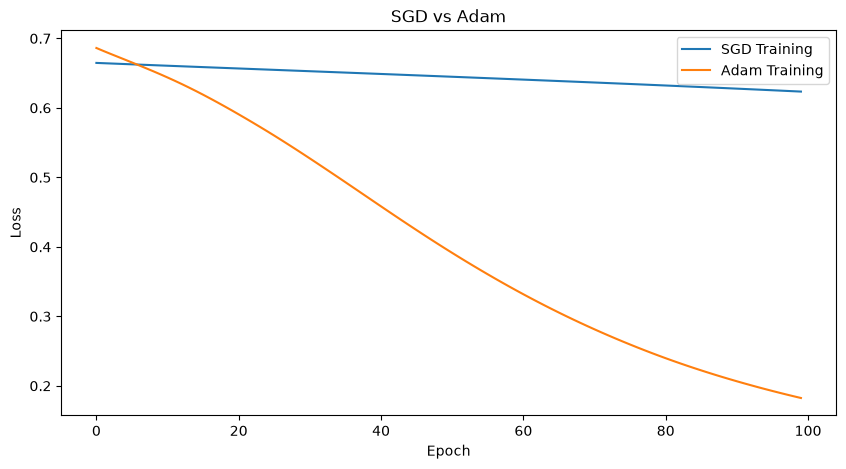

In [166]:
plt.figure(figsize=(10, 5))

plt.plot(sgd_losses, label="SGD Training")
plt.plot(adam_losses, label="Adam Training")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD vs Adam")
plt.legend()

plt.show()

In [167]:
model_sgd.eval()

with torch.no_grad():
    output = model_sgd(X_test)
    probabilities = torch.sigmoid(output)
    predictions = (probabilities >= 0.5).float()

sgd_accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy()
)

print(f"SGD Test Accuracy: {sgd_accuracy * 100:.2f}%")

SGD Test Accuracy: 62.79%


In [168]:
model_adam.eval()

with torch.no_grad():
    output = model_adam(X_test)
    probabilities = torch.sigmoid(output)
    predictions = (probabilities >= 0.5).float()

adam_accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy()
)

print(f"Adam Test Accuracy: {adam_accuracy * 100:.2f}%")

Adam Test Accuracy: 93.02%


In [169]:
class DropoutNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(30, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [170]:
model_dropout = DropoutNN()

optimizer_dropout = optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)

dropout_losses = []
dropout_val_losses = []

for epoch in range(epochs):

    model_dropout.train()

    output = model_dropout(X_train)

    train_loss = criterion(output, y_train)

    optimizer_dropout.zero_grad()

    train_loss.backward()

    optimizer_dropout.step()

    model_dropout.eval()

    with torch.no_grad():
        val_output = model_dropout(X_val)
        val_loss = criterion(val_output, y_val)

    dropout_losses.append(train_loss.item())
    dropout_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss = {train_loss.item():.4f}, "
            f"Val Loss = {val_loss.item():.4f}"
        )

Epoch 10: Train Loss = 0.6771, Val Loss = 0.6686
Epoch 20: Train Loss = 0.6342, Val Loss = 0.6209
Epoch 30: Train Loss = 0.5721, Val Loss = 0.5619
Epoch 40: Train Loss = 0.4935, Val Loss = 0.4889
Epoch 50: Train Loss = 0.4168, Val Loss = 0.4043
Epoch 60: Train Loss = 0.3269, Val Loss = 0.3190
Epoch 70: Train Loss = 0.2584, Val Loss = 0.2454
Epoch 80: Train Loss = 0.2061, Val Loss = 0.1898
Epoch 90: Train Loss = 0.1658, Val Loss = 0.1507
Epoch 100: Train Loss = 0.1480, Val Loss = 0.1238


In [171]:
class RegularizedNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(30, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [172]:
model_regularized = RegularizedNN()

optimizer_regularized = optim.Adam(
    model_regularized.parameters(),
    lr=0.001
)

regularized_losses = []
regularized_val_losses = []

for epoch in range(epochs):

    model_regularized.train()

    output = model_regularized(X_train)

    train_loss = criterion(output, y_train)

    optimizer_regularized.zero_grad()

    train_loss.backward()

    optimizer_regularized.step()

    model_regularized.eval()

    with torch.no_grad():
        val_output = model_regularized(X_val)
        val_loss = criterion(val_output, y_val)

    regularized_losses.append(train_loss.item())
    regularized_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss = {train_loss.item():.4f}, "
            f"Val Loss = {val_loss.item():.4f}"
        )

Epoch 10: Train Loss = 0.5771, Val Loss = 0.6312


Epoch 20: Train Loss = 0.5015, Val Loss = 0.5152
Epoch 30: Train Loss = 0.4462, Val Loss = 0.4345
Epoch 40: Train Loss = 0.4127, Val Loss = 0.3875
Epoch 50: Train Loss = 0.3870, Val Loss = 0.3586
Epoch 60: Train Loss = 0.3511, Val Loss = 0.3354
Epoch 70: Train Loss = 0.3222, Val Loss = 0.3137
Epoch 80: Train Loss = 0.3009, Val Loss = 0.2933
Epoch 90: Train Loss = 0.2771, Val Loss = 0.2735
Epoch 100: Train Loss = 0.2624, Val Loss = 0.2535


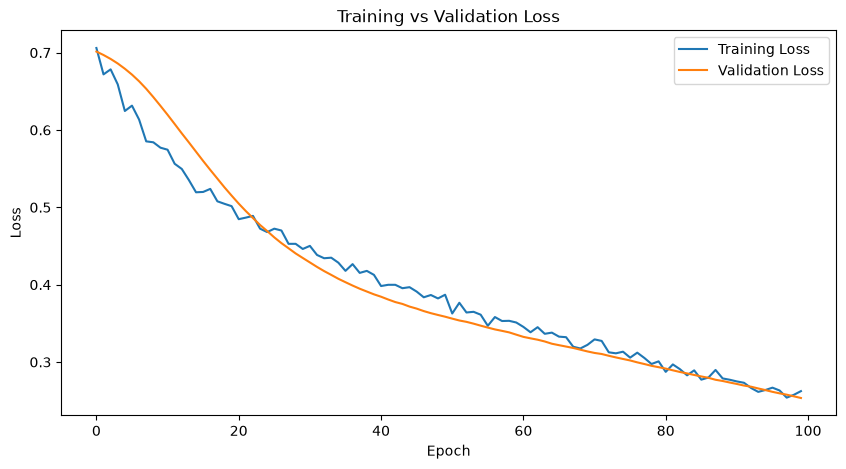

In [173]:
plt.figure(figsize=(10, 5))

plt.plot(
    regularized_losses,
    label="Training Loss"
)

plt.plot(
    regularized_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [174]:
model_regularized.eval()

with torch.no_grad():

    output = model_regularized(X_test)

    probabilities = torch.sigmoid(output)

    predictions = (probabilities >= 0.5).float()

accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy()
)

print(
    f"Regularized Model Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

Regularized Model Test Accuracy: 95.35%


In [175]:
print("SGD Accuracy:", sgd_accuracy)
print("Adam Accuracy:", adam_accuracy)
print("Regularized Accuracy:", accuracy)

SGD Accuracy: 0.627906976744186
Adam Accuracy: 0.9302325581395349
Regularized Accuracy: 0.9534883720930233


# Day 26 Summary

Today I studied optimizers and regularization techniques in PyTorch.

## Optimizers

- Compared SGD and Adam.
- Observed their training loss behavior.
- Evaluated their test performance.

## Regularization

- Implemented Dropout.
- Implemented Batch Normalization.
- Combined BatchNorm and Dropout in a neural network.

## Overfitting

- Compared training and validation loss.
- Learned how increasing validation loss while training loss decreases can indicate overfitting.

## Key Learning

Optimizers control how model weights are updated, while regularization techniques help the model generalize better to unseen data.